The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


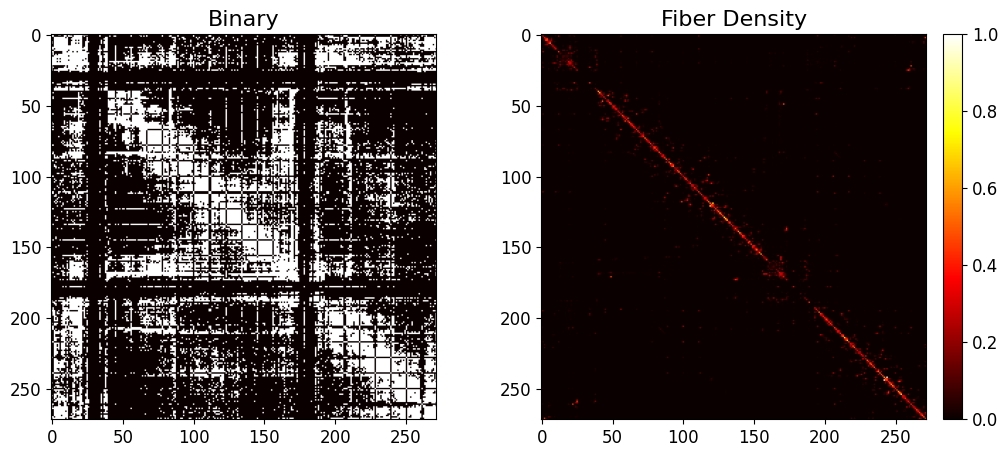

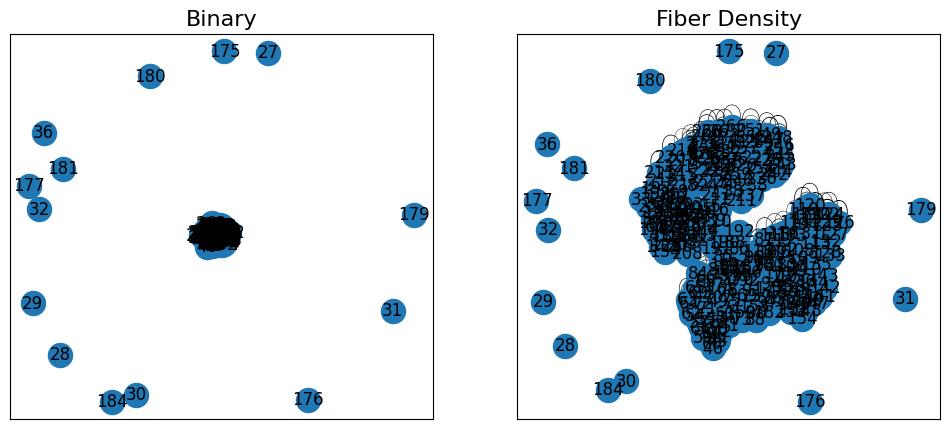

In [4]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt

from kuramoto.config import (
    SimulationConfig,
    GridConfig,
    CouplingConfig,
    InitThetaConfig,
    InitOmegaConfig,
    KernelComponentConfig,
    build_simulation,
)
from kuramoto.coupling import apply_node_lesions, plot_lesioned_coupling
from kuramoto.simulation import KuramotoParams
from kuramoto.analysis import (
    get_R, 
    compute_effective_coupling, 
    avg_effective_coupling,
    functional_connectivity,
    get_R_link,
)
from kuramoto.adjoint import (
    grads_mean_R,
    plot_basic_grads,
    get_adjoint_grads, 
    get_adjoint_metrics, 
    plot_adjoint_metrics,
)

from kuramoto.plotting import plot_2d, plot_coupling_matrix, set_plot_settings
from kuramoto.network import (
    create_cortical_graph,
    plot_graph_metrics,
    get_graph_metrics,
    plot_metric,
    plot_cortical_graph,
)

import networkx as nx
from pathlib import Path

from jax import numpy as jnp

set_plot_settings()

# Import connectome
CONN_PATH = Path("..\\data\\OASIS_N272\\sub-OAS30001_ses-d0757_atlas-L2018_res-scale3_conndata-network_connectivity.graphml")
G = nx.read_graphml(CONN_PATH)

nodes = sorted(G.nodes())
A_bin = nx.to_numpy_array(G, nodelist=nodes)
A_density = nx.to_numpy_array(G, nodelist=nodes, weight="normalized_fiber_density")

# Normalize to 0-1 
A_density = A_density / A_density.max()

G_bin = nx.from_numpy_array(A_bin)
G_density = nx.from_numpy_array(A_density)

ncols, nrows = A_density.shape

fig, ax = plt.subplots(1,2,figsize=(12, 5))
im1 = ax[0].imshow(A_bin, cmap="hot")
im2 = ax[1].imshow(A_density, cmap="hot")

ax[0].set_title("Binary")
ax[1].set_title("Fiber Density")

fig.colorbar(im2, ax=ax[1],fraction=0.046, pad=0.04)

# Plot Graphs
fig, ax = plt.subplots(1,2,figsize=(12, 5))

plot_cortical_graph(G_bin, layout="spring", ax=ax[0])
plot_cortical_graph(G_density, layout="spring", ax=ax[1])

ax[0].set_title("Binary")
ax[1].set_title("Fiber Density")

plt.show()

### 1) Build simulation and run

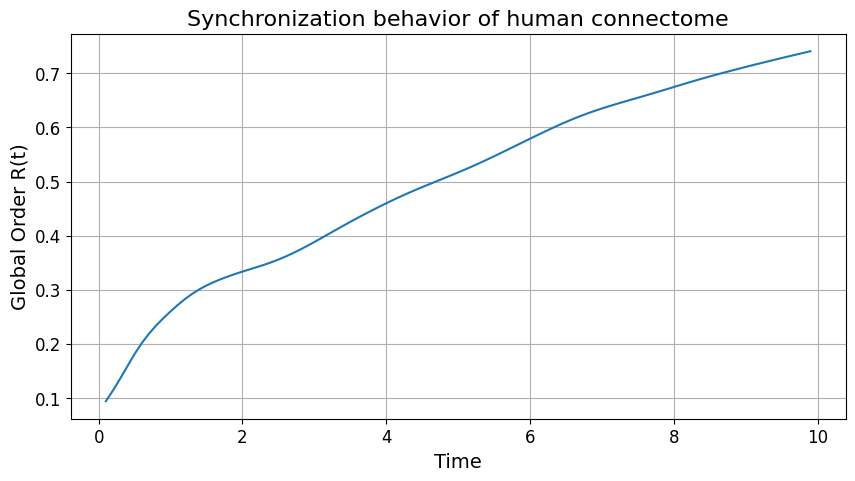

In [ ]:
SEED = 42
T_END = 10.0
dt = 0.1
RNG = np.random.default_rng(SEED)
N = A_density.shape[0]

K_BASE = 4.0
INIT_THETA = InitThetaConfig(mode="vonmises", mu=0.0, gamma=0.2)
INIT_OMEGA = InitOmegaConfig(mode="normal", mu=0.0, sigma=0.5)

cfg = SimulationConfig(
    coupling=CouplingConfig(
        K_matrix=A_density*K_BASE,
    ),
    initial_theta=INIT_THETA,
    initial_omega=INIT_OMEGA,
    seed=SEED,
)

sim = build_simulation(config=cfg, rng=np.random.default_rng(SEED))

grid_shape = sim.grid.shape

# Run base simulation
res_base = sim.run((0, T_END), dt, rng=RNG)

# Postprocess
R_list, _ = get_R(res_base['theta'])

K_eff_avg = avg_effective_coupling(sim.results["theta"], sim.coupling.K)
G_eff = create_cortical_graph(K_eff_avg, omega=sim.params.omega)

C_avg = functional_connectivity(sim.results["theta"], dt=dt)
G_C_avg = create_cortical_graph(C_avg, omega=sim.params.omega)

fig,ax = plt.subplots(figsize=(10,5))
ax.plot(res_base['ts'], R_list, linewidth=1.5)
ax.set_xlabel("Time")
ax.set_ylabel("Global Order R(t)")
ax.set_title("Synchronization behavior of human connectome")
ax.grid(True)

fig, ax = plt.subplots(1,2, figsize=(10, 5))


### Coupling strength sweep

Scale the normalized fiber-density matrix by a scalar **K** (same role as `Kf` in the grid bottleneck demo). For each **K** we rebuild the connectome simulation with the same random seed so only overall coupling strength changes, then record **R(t)**, time-mean **Rm**, and **R_link** from `postprocess=True`.

In [32]:
K_list = np.arange(0.1, 2, 0.1)

SWEEP_SEED = SEED

sweep_results = {
    "K": K_list,
    "Rm": [],
    "R_link": [],
    "R_t": [],
}

ts_sweep = None
for kf in K_list:
    cfg_k = SimulationConfig(
        coupling=CouplingConfig(K_matrix=A_density * kf * K_BASE),
        initial_theta=INIT_THETA,
        initial_omega=INIT_OMEGA,
        seed=SWEEP_SEED,
    )
    sim_k = build_simulation(config=cfg_k, rng=np.random.default_rng(SWEEP_SEED))
    res_k = sim_k.run(
        (0, T_END), dt, rng=np.random.default_rng(SWEEP_SEED), postprocess=True
    )
    if ts_sweep is None:
        ts_sweep = res_k["ts"]
    sweep_results["Rm"].append(float(res_k["Rm"]))
    sweep_results["R_link"].append(float(res_k["R_link"]))
    sweep_results["R_t"].append(res_k["R"])

print(f"Sweep done: {len(K_list)} values of K.")

Sweep done: 19 values of K.


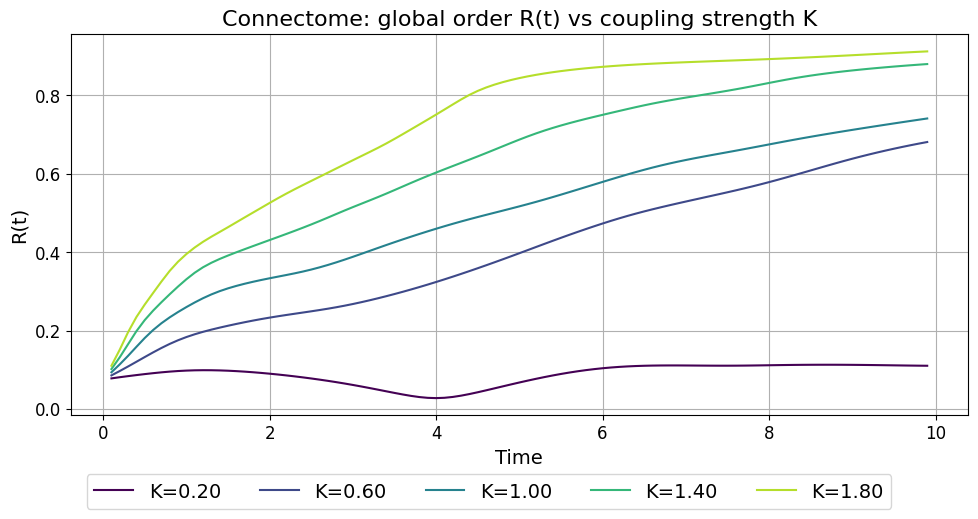

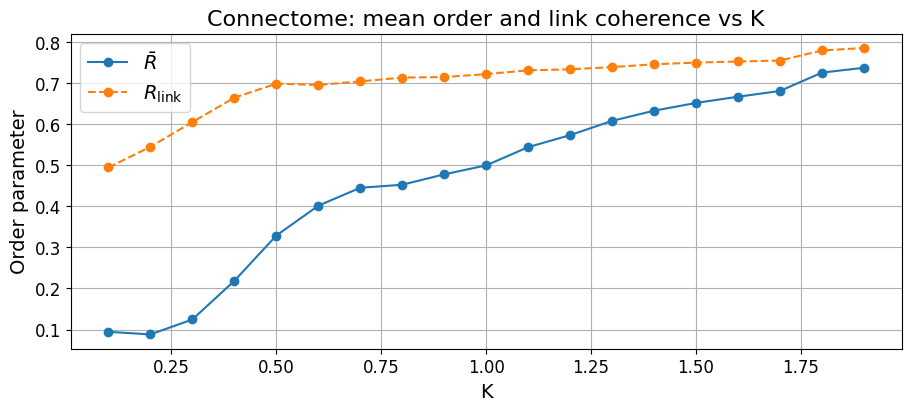

In [33]:
cmap = plt.colormaps["viridis"]
stride = 4
n_curves = max(len(K_list) - 1, 1)

fig, ax = plt.subplots(figsize=(10, 5))
for i, (kf, Rt) in enumerate(zip(K_list[1:-1:stride], sweep_results["R_t"][1:-1:stride])):
    c = cmap(i * stride / n_curves)
    ax.plot(ts_sweep, Rt, color=c, label=f"K={kf:.2f}")

ax.set_title("Connectome: global order R(t) vs coupling strength K")
ax.set_xlabel("Time")
ax.set_ylabel("R(t)")
ax.grid(True)
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=min(6, len(handles)), bbox_to_anchor=(0.5, -0.06))
plt.tight_layout()
plt.show()

# Mean R and R_link vs K
fig, ax = plt.subplots(figsize=(9, 4), constrained_layout=True)
ax.plot(sweep_results["K"], sweep_results["Rm"], marker="o", label=r"$\bar{R}$")
ax.plot(
    sweep_results["K"],
    sweep_results["R_link"],
    ls="--",
    marker="o",
    label=r"$R_{\mathrm{link}}$",
)
ax.set_title("Connectome: mean order and link coherence vs K")
ax.set_xlabel("K")
ax.set_ylabel("Order parameter")
ax.legend()
ax.grid(True)
plt.show()

### 2) Network theory metrics

Create derived graphs and evaluate relevant centrality / important metrics.

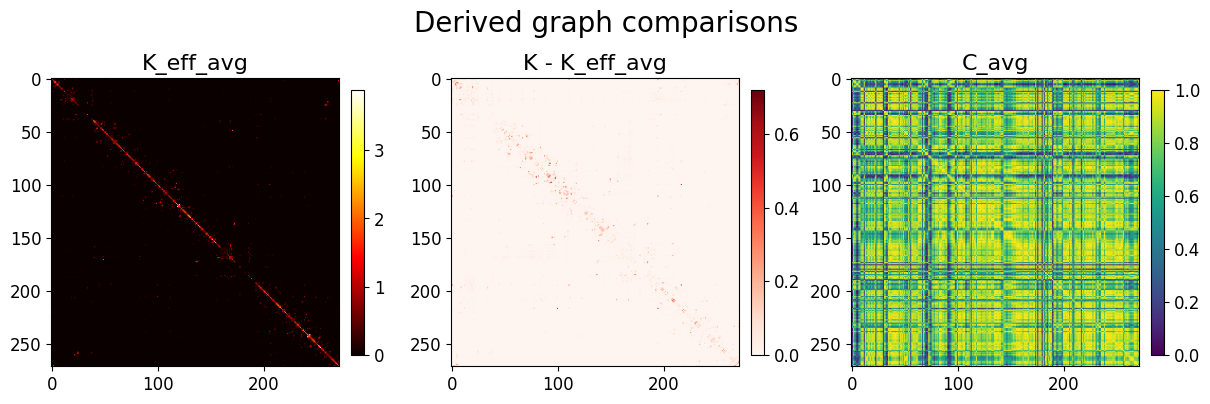

In [38]:
from matplotlib.colors import Normalize, CenteredNorm,TwoSlopeNorm

K_diff = sim.coupling.K - K_eff_avg

fig,ax = plt.subplots(1,3,figsize=(12,4),constrained_layout=True)
im = ax[0].imshow(K_eff_avg, norm=Normalize(vmin=0, vmax=np.max(K_eff_avg)), cmap="hot")
ax[0].set_title("K_eff_avg")
fig.colorbar(im,ax=ax[0],fraction=0.046, pad=0.04)

im = ax[1].imshow(K_diff, norm=Normalize(vmin=0,vmax=np.max(K_diff)), cmap="Reds")
ax[1].set_title("K - K_eff_avg")
fig.colorbar(im,ax=ax[1],fraction=0.046, pad=0.04)
fig.suptitle("Derived graph comparisons")

im = ax[2].imshow(C_avg, norm=Normalize(vmin=0,vmax=1), cmap="viridis")
ax[2].set_title("C_avg")
fig.colorbar(im,ax=ax[2],fraction=0.046, pad=0.04)

Text(0, 0.5, 'Functional Connectivity Graph')

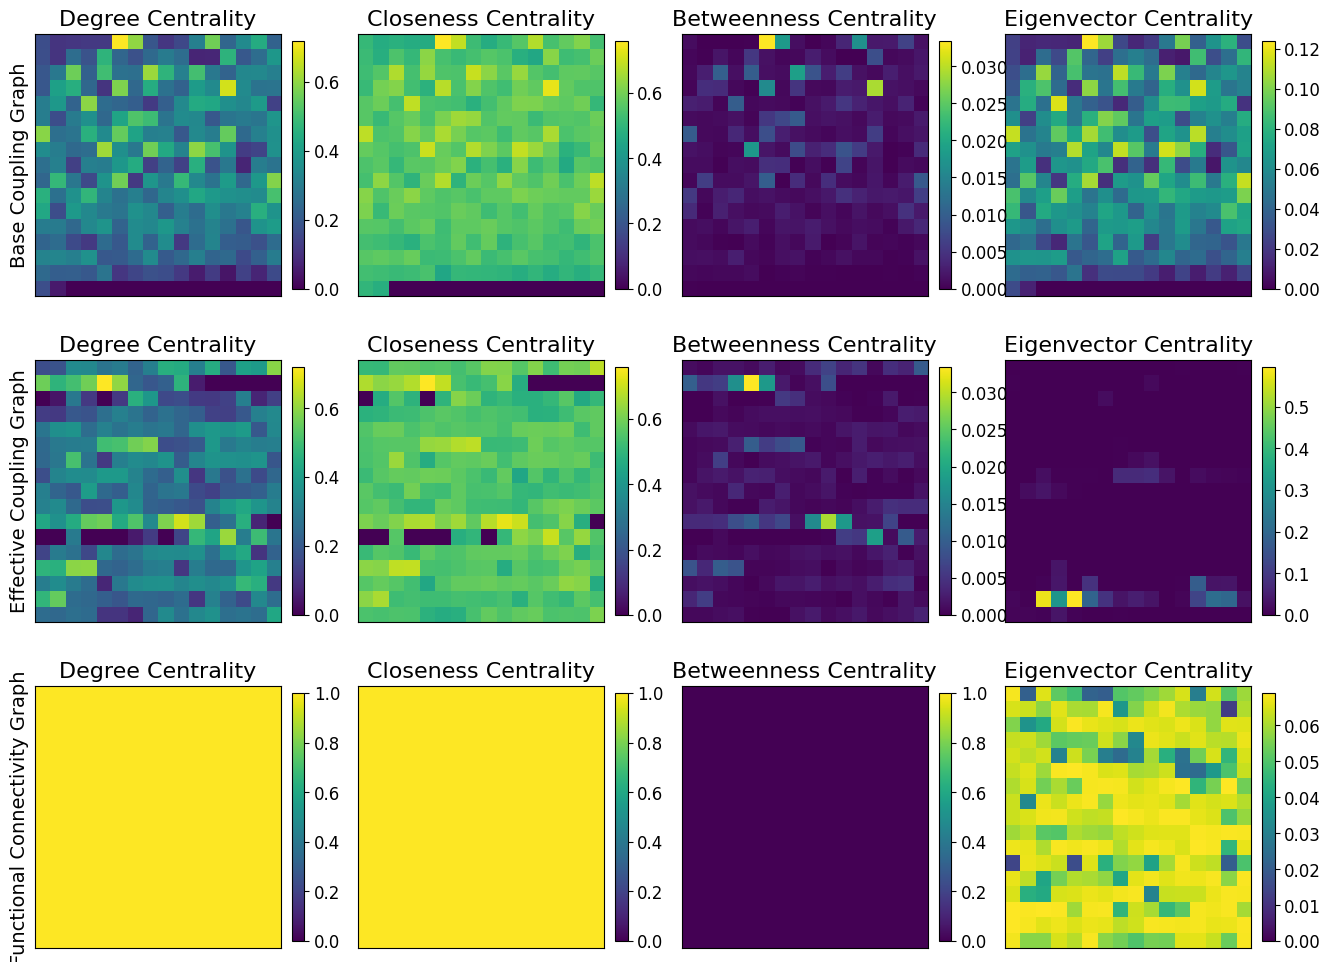

In [39]:
fig,axs = plt.subplots(3,4,figsize=(16,12))

plot_graph_metrics(G=G,grid_shape=grid_shape,axs=axs[0,:])
plot_graph_metrics(G=G_eff,grid_shape=grid_shape,axs=axs[1,:])
plot_graph_metrics(G=G_C_avg,grid_shape=grid_shape,axs=axs[2,:])

axs[0,0].set_ylabel("Base Coupling Graph")
axs[1,0].set_ylabel("Effective Coupling Graph")
axs[2,0].set_ylabel("Functional Connectivity Graph")

### 2) Adjoint metrics

  max |dR/dK| (averaged) = 2.071091e-01
  max |dR/domega| (averaged) = 2.037313e-01


(<Figure size 1200x500 with 4 Axes>,
 array([<Axes: title={'center': 'dJ/dK'}>,
        <Axes: title={'center': 'dJ/domega0'}>], dtype=object))

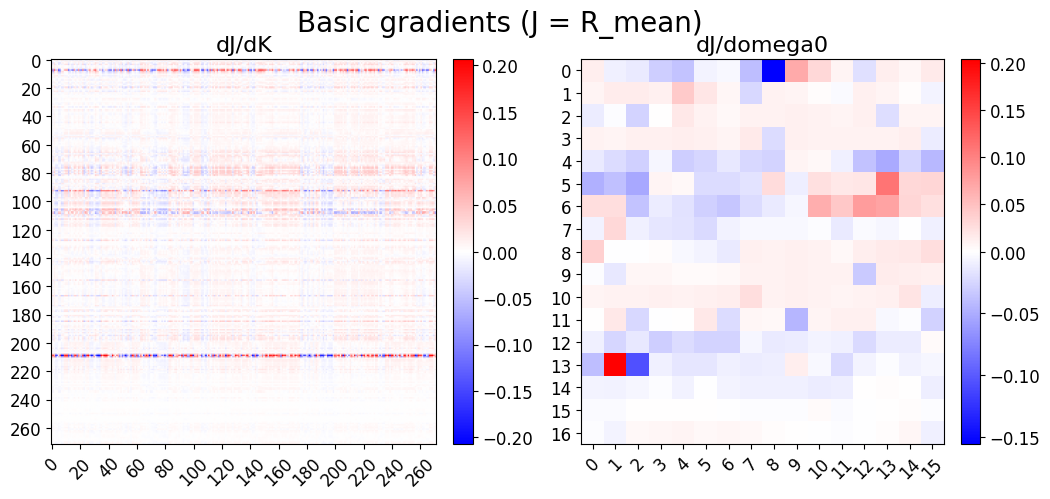

In [43]:
t0, t1 = 0.0, T_END
ts = jnp.arange(t0, t1 + dt / 2, dt)
ts = ts[ts <= t1]

g_avg = grads_mean_R(sim.params, sim.theta0, t0=0.0, t1=T_END, dt=dt, ts=ts)

dR_dK_avg = np.asarray(g_avg.K)
dR_domega_avg = np.asarray(g_avg.omega)
dR_domega_avg_2d = sim.grid.unflatten(dR_domega_avg)

# Statistics
print(f"  max |dR/dK| (averaged) = {float(np.max(np.abs(dR_dK_avg))):.6e}")
print(f"  max |dR/domega| (averaged) = {float(np.max(np.abs(dR_domega_avg))):.6e}")

plot_basic_grads(g_avg,grid_shape,title="Basic gradients (J = R_mean)")

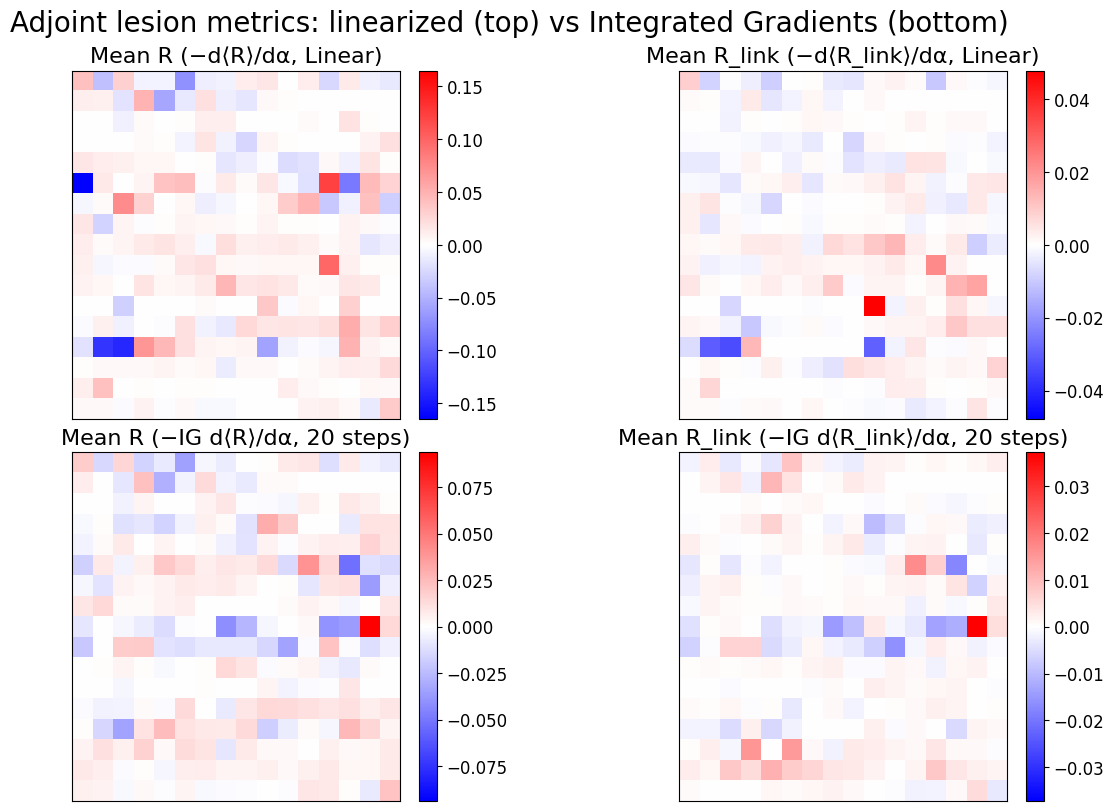

In [44]:
fig, axs = plot_adjoint_metrics(
    sim=sim,
    T_END=T_END,
    dt=dt,
    grid_shape=grid_shape,
    n_ig_steps=20,
    title="Adjoint lesion metrics: linearized (top) vs Integrated Gradients (bottom)",
)